In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
import scipy.cluster.hierarchy as shc
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

%matplotlib inline

# define data

### normalized data

In [2]:
df_normalized = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_normalized.csv')

In [3]:
df_normalized['Paced_music_mean_CV_iti'] = np.mean(df_normalized[['Paced_music_badine_mean_CV_iti', 'Paced_music_ross_mean_CV_iti']])

In [4]:
fiveash_columns = [
    'BAT_all_dprime',
    'Anisochrony_tones_threshold',
    'Unpaced_spontaneous_right_CV_iti',
    'SyncCont_metro_600_mean_CV_iti',
    'Paced_metro_600_mean_CV_iti',
]
#     'Paced_music_mean_CV_iti',


df_normalized_fivash = df_normalized[fiveash_columns]

### PCA data

<AxesSubplot: >

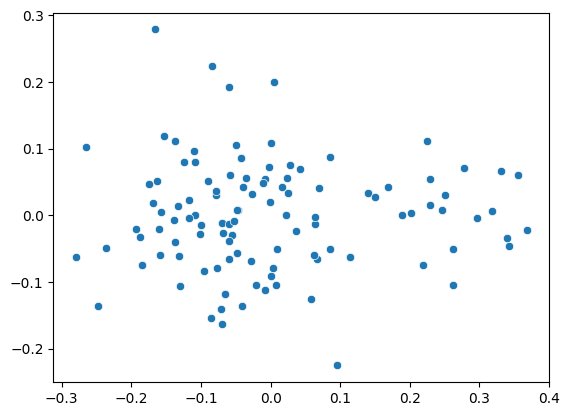

In [5]:
pca_norm = PCA(n_components=2)
pca_norm.fit(df_normalized.iloc[:,2:])
pca_normalized_data = pca_norm.transform(X=df_normalized.iloc[:,2:])
sns.scatterplot(x=pca_normalized_data[:,0], y=pca_normalized_data[:,1])

# GMM clustering

### On PCA

<AxesSubplot: >

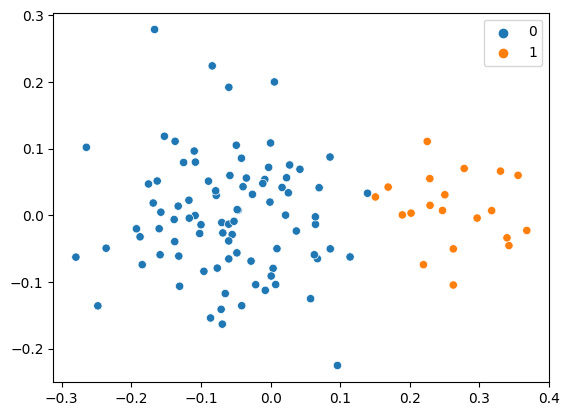

In [6]:
gmm = GaussianMixture(n_components=2, covariance_type='spherical').fit(pca_normalized_data)
labels = gmm.predict(pca_normalized_data)
sns.scatterplot(x=pca_normalized_data[:,0], y=pca_normalized_data[:,1], hue=labels)

### On tSNE

<AxesSubplot: >

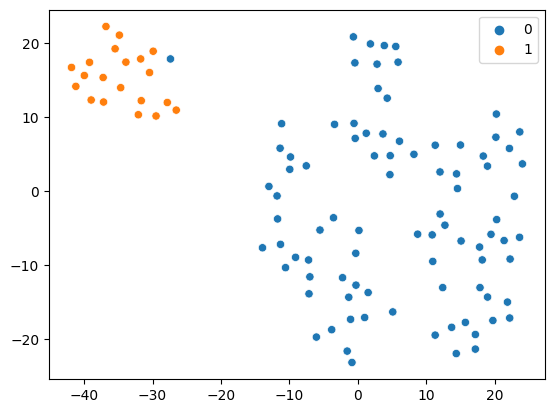

In [7]:
tsne_norm = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=10)
tsne_normalized_data = tsne_norm.fit_transform(df_normalized.iloc[:,2:])
sns.scatterplot(x=tsne_normalized_data[:,0], y=tsne_normalized_data[:,1], hue=labels)

# Fiveash data

### On PCA

In [8]:
df_normalized_fivash

,BAT_all_dprime,Anisochrony_tones_threshold,Unpaced_spontaneous_right_CV_iti,SyncCont_metro_600_mean_CV_iti,Paced_metro_600_mean_CV_iti
0,0.002748,0.004521,0.000033,0.000020,0.000023
1,0.001780,0.006671,0.000023,0.000028,0.000022
2,0.000821,0.002183,0.000026,0.000039,0.000035
3,0.002076,0.005381,0.000027,0.000020,0.000021
4,0.000420,0.007427,0.000022,0.000023,0.000025
...,...,...,...,...,...
103,0.000866,0.003848,0.000022,0.000024,0.000022
104,0.000952,0.007502,0.000040,0.000035,0.000040
105,0.000957,0.009071,0.000024,0.000015,0.000025
106,0.000654,0.013466,0.000035,0.000049,0.000034


<AxesSubplot: >

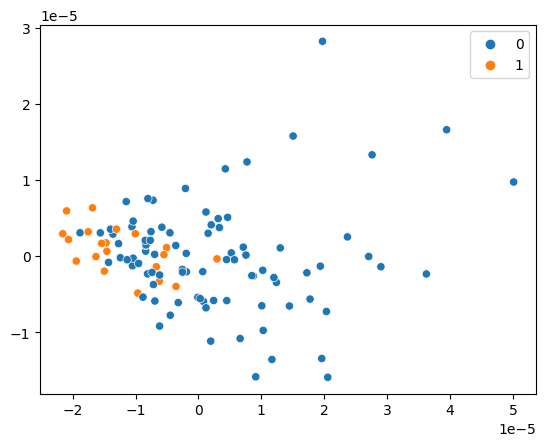

In [9]:
pca_norm_fivash = PCA(n_components=2)
pca_norm_fivash.fit(df_normalized_fivash.iloc[:,2:])
pca_normalized_data_fivash = pca_norm_fivash.transform(X=df_normalized_fivash.iloc[:,2:])
sns.scatterplot(x=pca_normalized_data_fivash[:,0], y=pca_normalized_data_fivash[:,1], hue=labels)

### On tSNE

<AxesSubplot: >

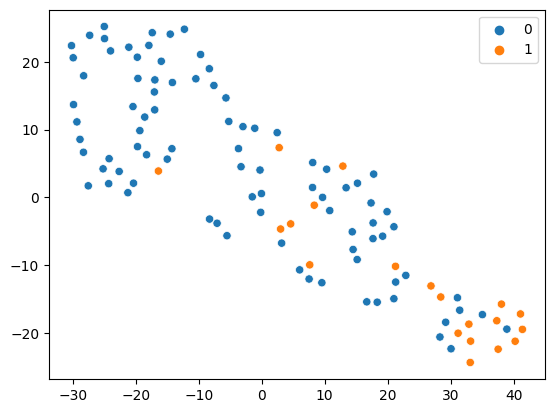

In [10]:
tsne_norm_fivash = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=10)
tsne_normalized_data_fivash = tsne_norm_fivash.fit_transform(df_normalized_fivash.iloc[:,2:])
sns.scatterplot(x=tsne_normalized_data_fivash[:,0], y=tsne_normalized_data_fivash[:,1], hue=labels)

# correlation of pca result with original columns

### pearson

In [11]:
df_normalized['pca_first'] = pca_normalized_data[:,0]
df_normalized['pca_second'] = pca_normalized_data[:,1]

<AxesSubplot: >

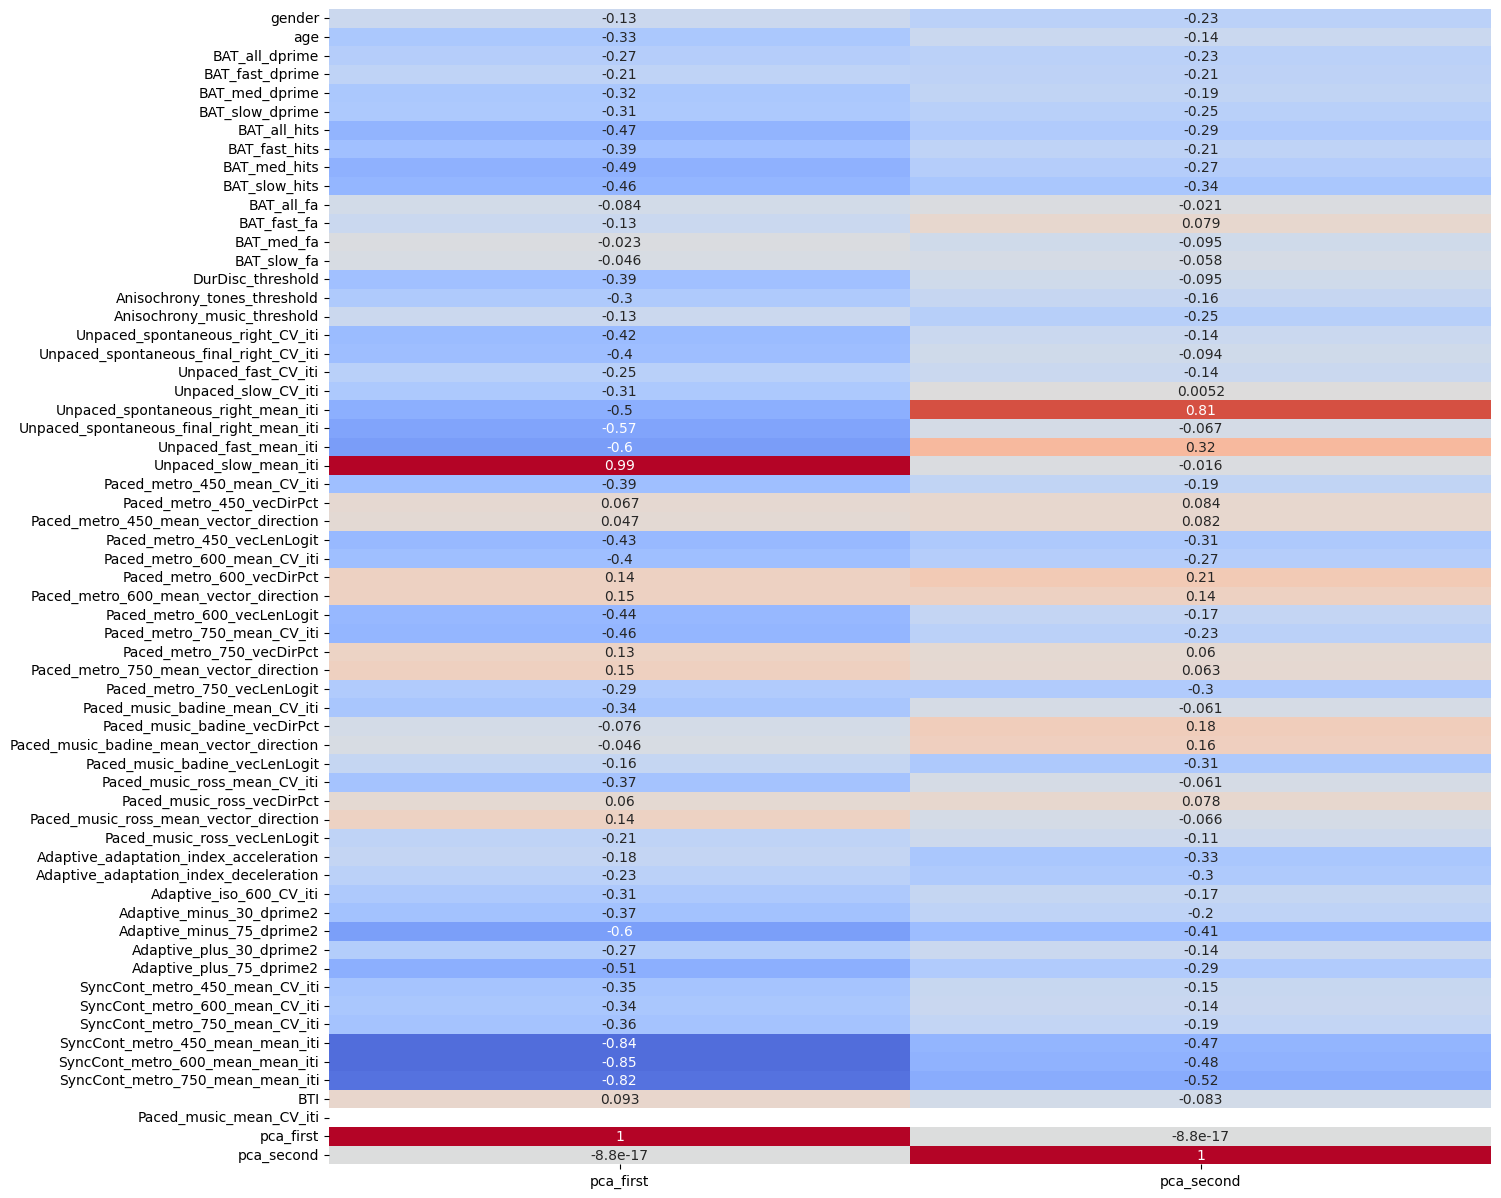

In [12]:
pearson_corr = df_normalized.iloc[:,2:].corr(method='pearson')
plt.figure(figsize=(15,15))
corr_results = pearson_corr[['pca_first','pca_second']]
sns.heatmap(data=corr_results, vmin=-1, vmax=1, cmap='coolwarm', cbar=False, annot=True)

In [13]:
df_normalized['Unpaced_spontaneous_right_mean_iti']

0      0.367033
1      0.278919
2      0.324944
3      0.297059
4      0.269117
         ...   
103    0.374881
104    0.341512
105    0.351881
106    0.416633
107    0.228022
Name: Unpaced_spontaneous_right_mean_iti, Length: 108, dtype: float64

# comparison of Fivash and full

In [ ]:
df_normalized_fivash['fivash_pca_first'] = pca_normalized_data_fivash[:,0]
df_normalized_fivash['fivash_pca_second'] = pca_normalized_data_fivash[:,1]
df_normalized_fivash['fivash_pca_third'] = pca_normalized_data_fivash[:,2]
df_normalized_fivash['fivash_pca_fourth'] = pca_normalized_data_fivash[:,3]